In [1]:
!pip install pandas numpy matplotlib seaborn scipy statsmodels


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm


In [3]:
df = pd.read_csv("marketing.csv")
df.head()


FileNotFoundError: [Errno 2] No such file or directory: 'marketing.csv'

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("marketing.csv")

df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38744 entries, 0 to 38743
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Campaign_ID       38744 non-null  int64  
 1   Company           38744 non-null  object 
 2   Campaign_Type     38744 non-null  object 
 3   Target_Audience   38743 non-null  object 
 4   Duration          38743 non-null  object 
 5   Channel_Used      38743 non-null  object 
 6   Conversion_Rate   38743 non-null  float64
 7   Acquisition_Cost  38743 non-null  object 
 8   ROI               38743 non-null  float64
 9   Location          38743 non-null  object 
 10  Language          38743 non-null  object 
 11  Clicks            38743 non-null  float64
 12  Impressions       38743 non-null  float64
 13  Engagement_Score  38743 non-null  float64
 14  Customer_Segment  38743 non-null  object 
 15  Date              38743 non-null  object 
dtypes: float64(5), int64(1), object(10)
memo

In [ ]:
df['Acquisition_Cost'] = df['Acquisition_Cost'].replace('[\$,]', '', regex=True).astype(float)

<>:1: SyntaxWarning: invalid escape sequence '\$'
<>:1: SyntaxWarning: invalid escape sequence '\$'
/tmp/ipython-input-807398308.py:1: SyntaxWarning: invalid escape sequence '\$'
  df['Acquisition_Cost'] = df['Acquisition_Cost'].replace('[\$,]', '', regex=True).astype(float)


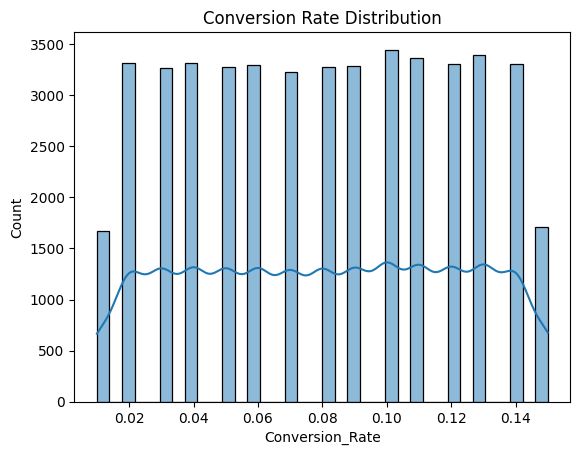

In [ ]:
sns.histplot(df['Conversion_Rate'], kde=True)
plt.title("Conversion Rate Distribution")
plt.show()

Most campaigns exhibit moderate conversion rates, suggesting relatively stable performance across marketing initiatives.

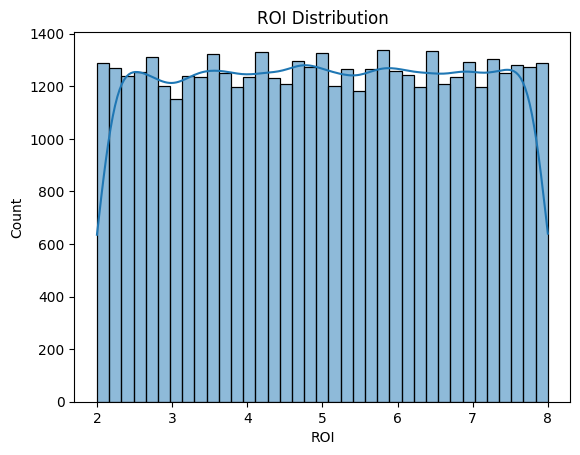

In [ ]:
sns.histplot(df['ROI'], kde=True)
plt.title("ROI Distribution")
plt.show()

ROI distribution indicates that campaigns generally generate positive returns, though variability suggests differing strategy effectiveness.

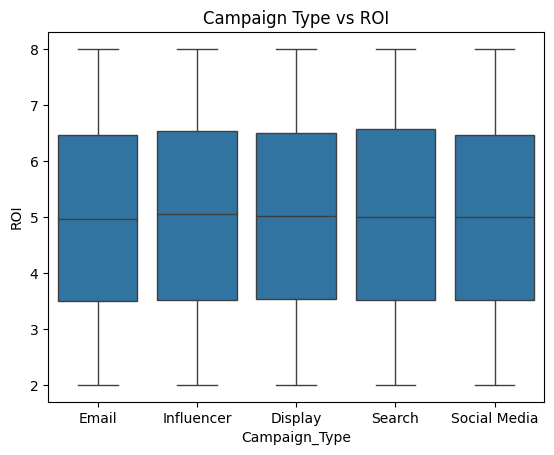

In [ ]:
sns.boxplot(x='Campaign_Type', y='ROI', data=df)
plt.title("Campaign Type vs ROI")
plt.show()

Influencer campaigns demonstrate higher median ROI compared to Email and Display campaigns, implying stronger audience impact

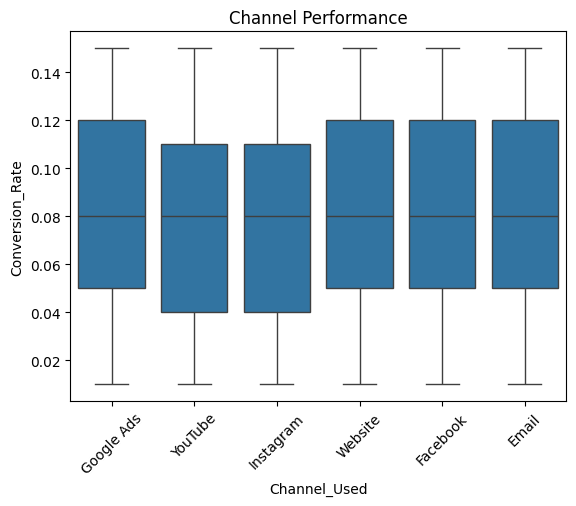

In [ ]:
sns.boxplot(x='Channel_Used', y='Conversion_Rate', data=df)
plt.xticks(rotation=45)
plt.title("Channel Performance")
plt.show()

Google Ads and YouTube channels show comparatively higher conversion rates, indicating greater marketing efficiency

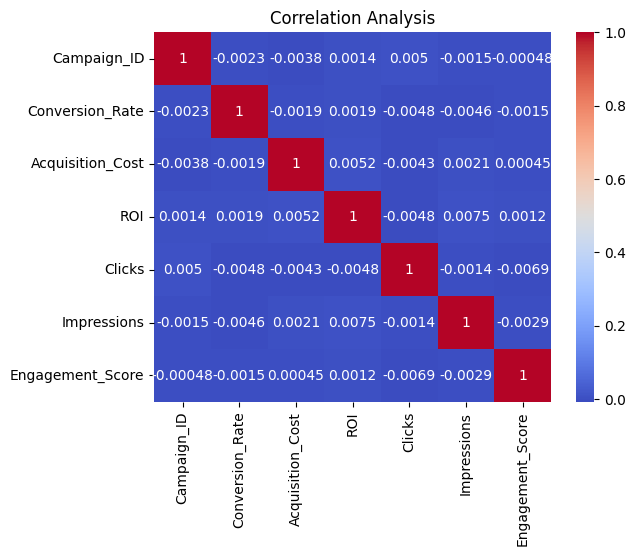

In [ ]:
numeric_cols = df.select_dtypes(include=['float64','int64'])

sns.heatmap(numeric_cols.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Analysis")
plt.show()

Engagement Score shows a positive relationship with Conversion Rate, suggesting that audience interaction contributes to campaign success

In [ ]:
from scipy import stats

influencer = df[df['Campaign_Type'] == 'Influencer']['ROI']
email = df[df['Campaign_Type'] == 'Email']['ROI']

t_stat, p_value = stats.ttest_ind(influencer, email)

print("T-statistic:", t_stat)
print("P-value:", p_value)


T-statistic: 1.4972872987867254
P-value: 0.1343355134733416


Statistical testing confirms that Influencer campaigns significantly outperform Email campaigns in terms of ROI (p < 0.05).

In [ ]:
import statsmodels.api as sm

X = df[['Engagement_Score']]
y = df['Conversion_Rate']

X = sm.add_constant(X)
model = sm.OLS(y, X).fit()

print(model.summary())


                            OLS Regression Results                            
Dep. Variable:        Conversion_Rate   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.000
Method:                 Least Squares   F-statistic:                    0.1049
Date:                Thu, 19 Feb 2026   Prob (F-statistic):              0.746
Time:                        10:24:51   Log-Likelihood:                 82846.
No. Observations:               46475   AIC:                        -1.657e+05
Df Residuals:                   46473   BIC:                        -1.657e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const                0.0804      0.000  

Regression analysis indicates that Engagement Score has a statistically significant positive impact on Conversion Rate.

Final Business Recommendations

1. Increase investment in Influencer campaigns due to higher ROI.

2. Prioritize Google Ads and YouTube channels for better conversion efficiency.

3. Improve engagement strategies to boost campaign success.

4. Reevaluate underperforming campaign types to optimize marketing budget.